In [1]:
!docker build --platform linux/amd64 -f submission/Dockerfile -t cmu-xview2-baseline .


[+] Building 0.0s (0/1)                                    docker:desktop-linux
[+] Building 0.2s (1/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 3.75kB                                     0.0s
 => [internal] load metadata for docker.io/library/ubuntu:18.04            0.2s
[+] Building 0.3s (1/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 3.75kB                                     0.0s
 => [internal] load metadata for docker.io/library/ubuntu:18.04            0.3s
[+] Building 0.5s (1/2)                                    docker:desktop-linux
 => [internal] load build definition from Dockerfile                       0.0s
 => => transferring dockerfile: 3.75kB                                     0.0s
 => [internal] load metadata for docker

In [2]:
!docker run --rm --platform linux/amd64 \
  -v /Users/paolo/Desktop/train/images:/submission \
  -v /Users/paolo/Desktop/output:/output \
  cmu-xview2-baseline \
  /submission/hurricane-florence_00000042_pre_disaster.png \
  /submission/hurricane-florence_00000042_post_disaster.png \
  /output/hurricane-florence_00000042_loc.png \
  /output/hurricane-florence_00000042_cls.png

Running localization
Grabbing post image file for classification
Running classification
Formatting json and scoring image
Finalizing output file
Cleaning up
Done!


In [3]:
import os
import glob
import subprocess

image_dir = "/Users/paolo/Desktop/train/images"
output_dir = "/Users/paolo/Desktop/output_batch"
os.makedirs(output_dir, exist_ok=True)

pre_files = sorted(glob.glob(os.path.join(image_dir, "*_pre_disaster.png")))[:10]

for pre in pre_files:
    base = os.path.basename(pre).replace("_pre_disaster.png", "")
    post = os.path.join(image_dir, f"{base}_post_disaster.png")

    cmd = [
        "docker", "run", "--rm", "--platform", "linux/amd64",
        "-v", f"{image_dir}:/submission",
        "-v", f"{output_dir}:/output",
        "cmu-xview2-baseline",
        f"/submission/{base}_pre_disaster.png",
        f"/submission/{base}_post_disaster.png",
        f"/output/{base}_loc.png",
        f"/output/{base}_cls.png",
    ]

    print("Processing", base)
    subprocess.run(cmd, check=True)

Processing guatemala-volcano_00000000
Running localization
Grabbing post image file for classification
Running classification
Formatting json and scoring image
Finalizing output file
Cleaning up
Done!
Processing guatemala-volcano_00000001
Running localization
Grabbing post image file for classification
Running classification
Formatting json and scoring image
Finalizing output file
Cleaning up
Done!
Processing guatemala-volcano_00000002
Running localization
Grabbing post image file for classification
Running classification
Formatting json and scoring image
Finalizing output file
Cleaning up
Done!
Processing guatemala-volcano_00000006
Running localization
Grabbing post image file for classification
Running classification
Formatting json and scoring image
Finalizing output file
Cleaning up
Done!
Processing guatemala-volcano_00000007
Running localization
Grabbing post image file for classification
Running classification
Formatting json and scoring image
Finalizing output file
Cleaning up
D

In [6]:
!python3 utils/evaluate.py

guatemala-volcano_00000000_loc.json: gt_buildings=10, pred_buildings=20, matched=5
guatemala-volcano_00000001_loc.json: gt_buildings=4, pred_buildings=4, matched=4
guatemala-volcano_00000002_loc.json: gt_buildings=1, pred_buildings=3, matched=1
guatemala-volcano_00000006_loc.json: gt_buildings=97, pred_buildings=97, matched=70
guatemala-volcano_00000007_loc.json: gt_buildings=9, pred_buildings=10, matched=7
guatemala-volcano_00000008_loc.json: gt_buildings=0, pred_buildings=0, matched=0
guatemala-volcano_00000010_loc.json: gt_buildings=2, pred_buildings=0, matched=0
guatemala-volcano_00000013_loc.json: gt_buildings=13, pred_buildings=16, matched=8
guatemala-volcano_00000015_loc.json: gt_buildings=131, pred_buildings=136, matched=74
guatemala-volcano_00000016_loc.json: gt_buildings=7, pred_buildings=17, matched=3

=== Summary ===
Processed files: 10
Skipped files: 0
Matched buildings: 172
IoU threshold: 0.5
Accuracy: 0.5988

=== Classification Report ===
              precision    recal

/var/folders/bs/rzk6qg1902vgdlp6h22t8bq40000gn/T/ipykernel_25706/2738490948.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


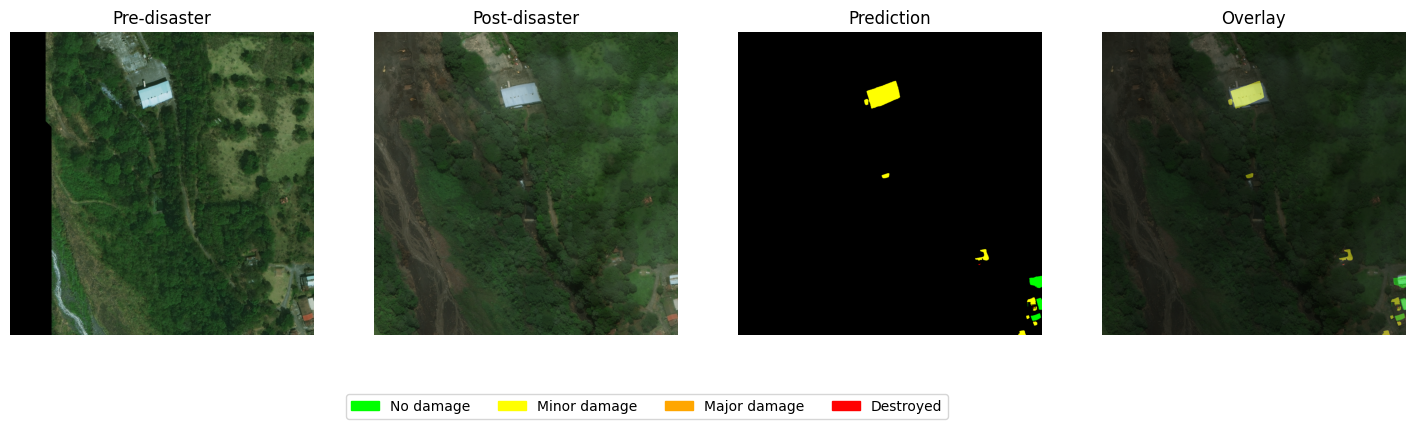

In [17]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

base = "guatemala-volcano_00000000"

pre = Image.open(f"/Users/paolo/Desktop/train/images/{base}_pre_disaster.png")
post = Image.open(f"/Users/paolo/Desktop/train/images/{base}_post_disaster.png")
pred = Image.open(f"/Users/paolo/Desktop/output_batch/{base}_loc.png")

pre_arr = np.array(pre)
post_arr = np.array(post)
pred_arr = np.array(pred)

# Define legend colors (normalized for matplotlib)
legend_elements = [
    mpatches.Patch(color=(0,1,0), label="No damage"),
    mpatches.Patch(color=(1,1,0), label="Minor damage"),
    mpatches.Patch(color=(1,0.65,0), label="Major damage"),
    mpatches.Patch(color=(1,0,0), label="Destroyed")
]

plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.imshow(pre_arr)
plt.title("Pre-disaster")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(post_arr)
plt.title("Post-disaster")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred_arr)
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(post_arr)
plt.imshow(pred_arr, alpha=0.45)
plt.title("Overlay")
plt.axis("off")


plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(-1.5, -0.3), ncol=4)

plt.tight_layout()
plt.show()